In [16]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing


## Walmart

!Question Exam June 2024!

Below are Wal-Mart's quarterly sales (expressed in billion dollars)
1. Convert the “startdate” to the datatype datetime.
2. Create the plot below.

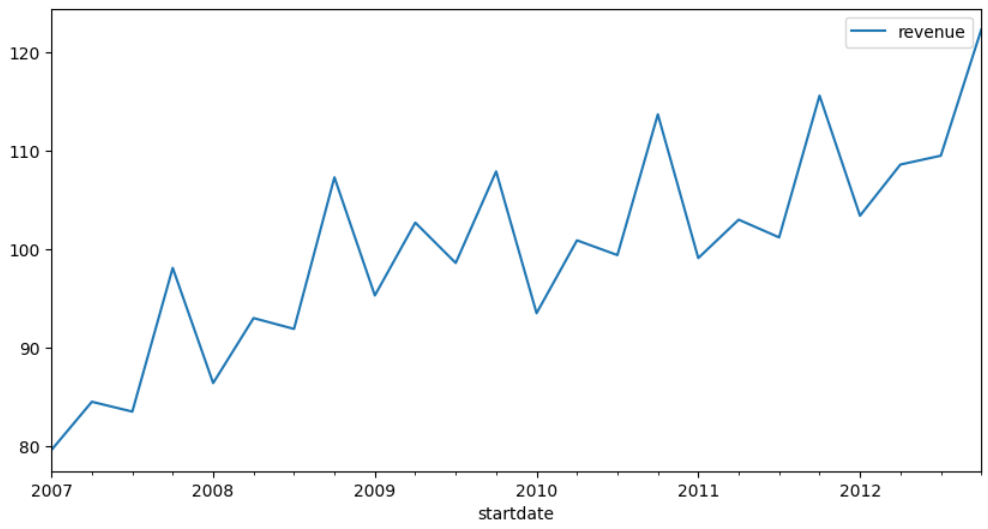

3. Make a forecast for next accounting year's sales using the most appropriate method. Explain why you chose this method.
4. Make a plot including the forecast for the next accounting year.
5. In which quarter will sales exceed $150 billion for the first time? [2018-10-01]

In [2]:
dfwalmart = pd.DataFrame(data={
    'startdate': ['2007/01/01', '2007/04/01', '2007/07/01', '2007/10/01', '2008/01/01', '2008/04/01', '2008/07/01', '2008/10/01','2009/01/01', '2009/04/01', '2009/07/01', '2009/10/01','2010/01/01', '2010/04/01', '2010/07/01', '2010/10/01','2011/01/01', '2011/04/01', '2011/07/01', '2011/10/01','2012/01/01', '2012/04/01', '2012/07/01', '2012/10/01'],
    'quarter': ['2007-1','2007-2','2007-3','2007-4','2008-1','2008-2','2008-3','2008-4','2009-1','2009-2','2009-3','2009-4','2010-1','2010-2','2010-3','2010-4','2011-1','2011-2','2011-3','2011-4','2012-1','2011-2','2011-3','2011-4'],
    'revenue': [79.6,84.5,83.5,98.1,86.4,93,91.9,107.3,95.3,102.7,98.6,107.9,93.5,100.9,99.4,113.7,99.1,103,101.2,115.6,103.4,108.6,109.5,122.3]
})

dfwalmart.head()

,startdate,quarter,revenue
0,2007/01/01,2007-1,79.6
1,2007/04/01,2007-2,84.5
2,2007/07/01,2007-3,83.5
3,2007/10/01,2007-4,98.1
4,2008/01/01,2008-1,86.4


In [ ]:
# 1. Convert the “startdate” to the datatype datetime.
dfwalmart['startdate'] = pd.to_datetime(dfwalmart['startdate'])

# Optioneel maar aangeraden: zet de datum als index voor makkelijkere analyse
dfwalmart.set_index('startdate', inplace=True)
dfwalmart.head()

,quarter,revenue
startdate,,
2007-01-01,2007-1,79.6
2007-04-01,2007-2,84.5
2007-07-01,2007-3,83.5
2007-10-01,2007-4,98.1
2008-01-01,2008-1,86.4


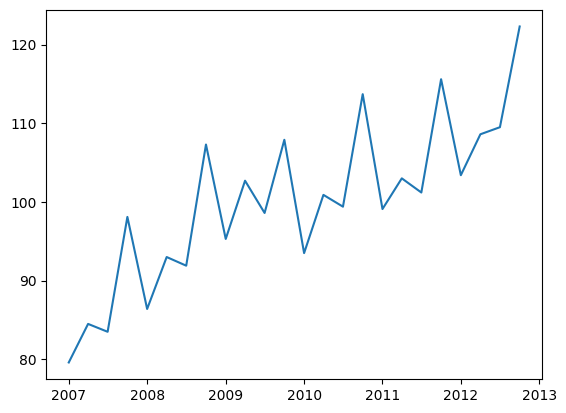

In [5]:
# 2. Create the plot below.
plt.plot(dfwalmart.index, dfwalmart['revenue'])


In [18]:
# 3. Make a forecast for next accounting year's sales using the most appropriate method. Explain why you chose this method.

data = ExponentialSmoothing(dfwalmart['revenue'], trend='add', seasonal='add', seasonal_periods=4)
datamodel = data.fit()

modelforecast = datamodel.forecast(4)
print(modelforecast)

2013-01-01    109.320000
2013-04-01    115.220000
2013-07-01    113.786667
2013-10-01    127.253334
Freq: QS-OCT, dtype: float64


/home/seppevo/repo/dsai-labs/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


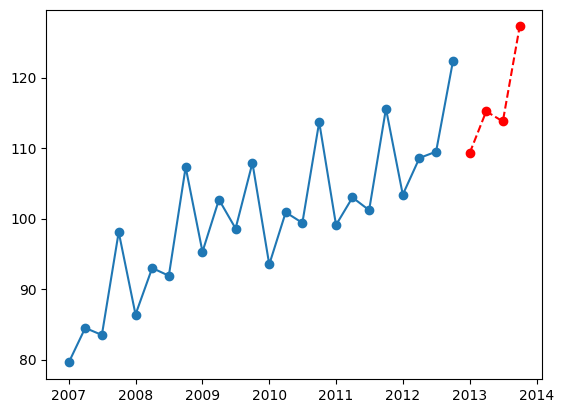

In [24]:
# 4.Make a plot including the forecast for the next accounting year.

# Historische data
plt.plot(dfwalmart.index, dfwalmart['revenue'], marker='o', label='Historical Revenue')

# Voorspelling (zorg dat de X-as klopt door een datum-index aan te maken voor de forecast)
forecast_dates = pd.date_range(start=dfwalmart.index[-1] + pd.DateOffset(months=3), periods=4, freq='QS')
modelforecast.index = forecast_dates

plt.plot(modelforecast.index, modelforecast, marker='o', color='red', linestyle='--', label='Forecast (Next Year)')

plt.show()

In [31]:
# 5. In which quarter will sales exceed $150 billion for the first time?

# 5. In which quarter will sales exceed $150 billion for the first time? [2018-10-01]

# Verleng de voorspelling (bijv. 30 kwartalen vooruit)
long_forecast = fitted_model.forecast(30)
long_forecast_dates = pd.date_range(start=dfwalmart.index[-1] + pd.DateOffset(months=3), periods=30, freq='QS')
long_forecast.index = long_forecast_dates

# Filter de waarden om degene te vinden die groter zijn dan 150
exceed_150 = long_forecast[long_forecast > 150]

# Pak de allereerste datum waarop dit gebeurt
first_time_date = exceed_150.index[0]

print(f"Sales will exceed $150 billion for the first time on: {first_time_date.date()}")

Sales will exceed $150 billion for the first time on: 2018-10-01
